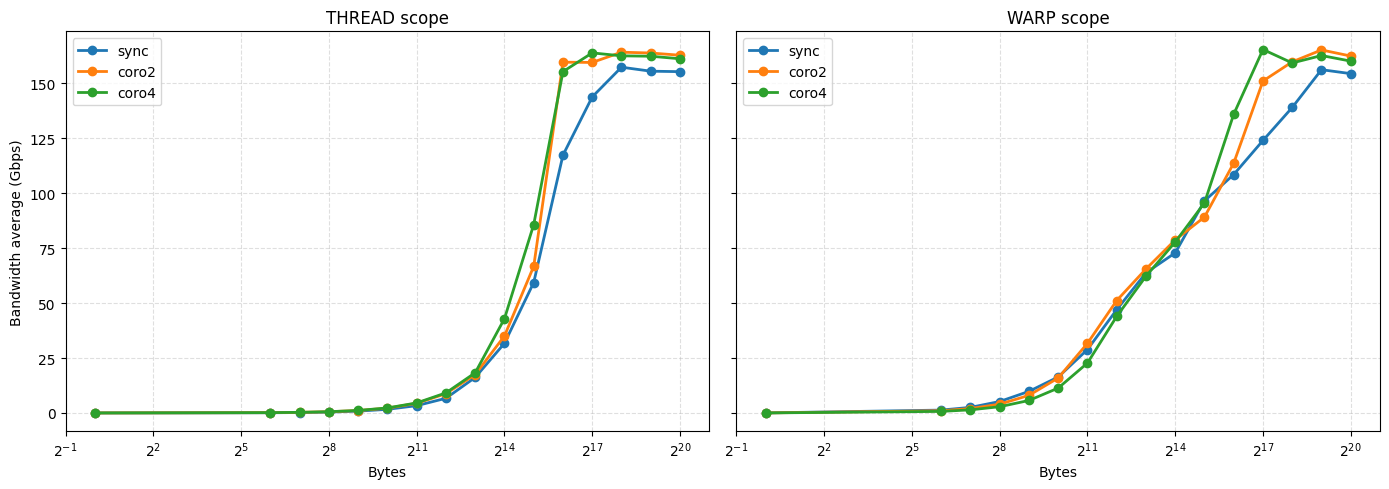

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 配置
# =========================
files = {
    "sync": "/home/tyh/gpunetio/test/191c_191s/put_bw/put_bw.csv",
    "coro2": "/home/tyh/gpunetio/test/191c_191s/put_bw_coro2/put_bw_coro2.csv",
    "coro4": "/home/tyh/gpunetio/test/191c_191s/put_bw_coro4/put_bw_coro4.csv",
}

# 如果只画某个 threads，例如 1 / 2 / 4 / 8 / 16 / 32，设置为对应数字
# 如果为 None，则对不同 threads 取最大 bw_average_bps
THREADS_FILTER = None

# =========================
# 读取并合并数据
# =========================
dfs = []

for name, file in files.items():
    path = Path(file)
    if not path.exists():
        raise FileNotFoundError(f"找不到文件: {file}")

    df = pd.read_csv(path)
    df["version"] = name

    # 原始 CSV 中是 bw_average_Gbps，这里转换为 bps
    if "bw_average_bps" not in df.columns:
        df["bw_average_bps"] = df["bw_average_Gbps"] * 1e9

    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# =========================
# 处理 threads
# =========================
if THREADS_FILTER is not None:
    plot_data = data[data["threads"] == THREADS_FILTER].copy()
else:
    # 每个 version / scope / bytes 下，对不同 threads 取最大带宽
    plot_data = (
        data
        .groupby(["version", "scope", "bytes"], as_index=False)["bw_average_bps"]
        .max()
    )

# =========================
# bps 转 Gbps
# =========================
plot_data["bw_average_Gbps"] = plot_data["bw_average_bps"] / 1e9

# =========================
# 画图
# =========================
scopes = ["THREAD", "WARP"]
versions = ["sync", "coro2", "coro4"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, scope in zip(axes, scopes):
    scope_df = plot_data[plot_data["scope"] == scope]

    for version in versions:
        vdf = scope_df[scope_df["version"] == version].sort_values("bytes")

        ax.plot(
            vdf["bytes"],
            vdf["bw_average_Gbps"],
            marker="o",
            linewidth=2,
            label=version,
        )

    ax.set_title(f"{scope} scope")
    ax.set_xlabel("Bytes")
    ax.set_xscale("log", base=2)
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    ax.legend()

axes[0].set_ylabel("Bandwidth average (Gbps)")

plt.tight_layout()
plt.show()

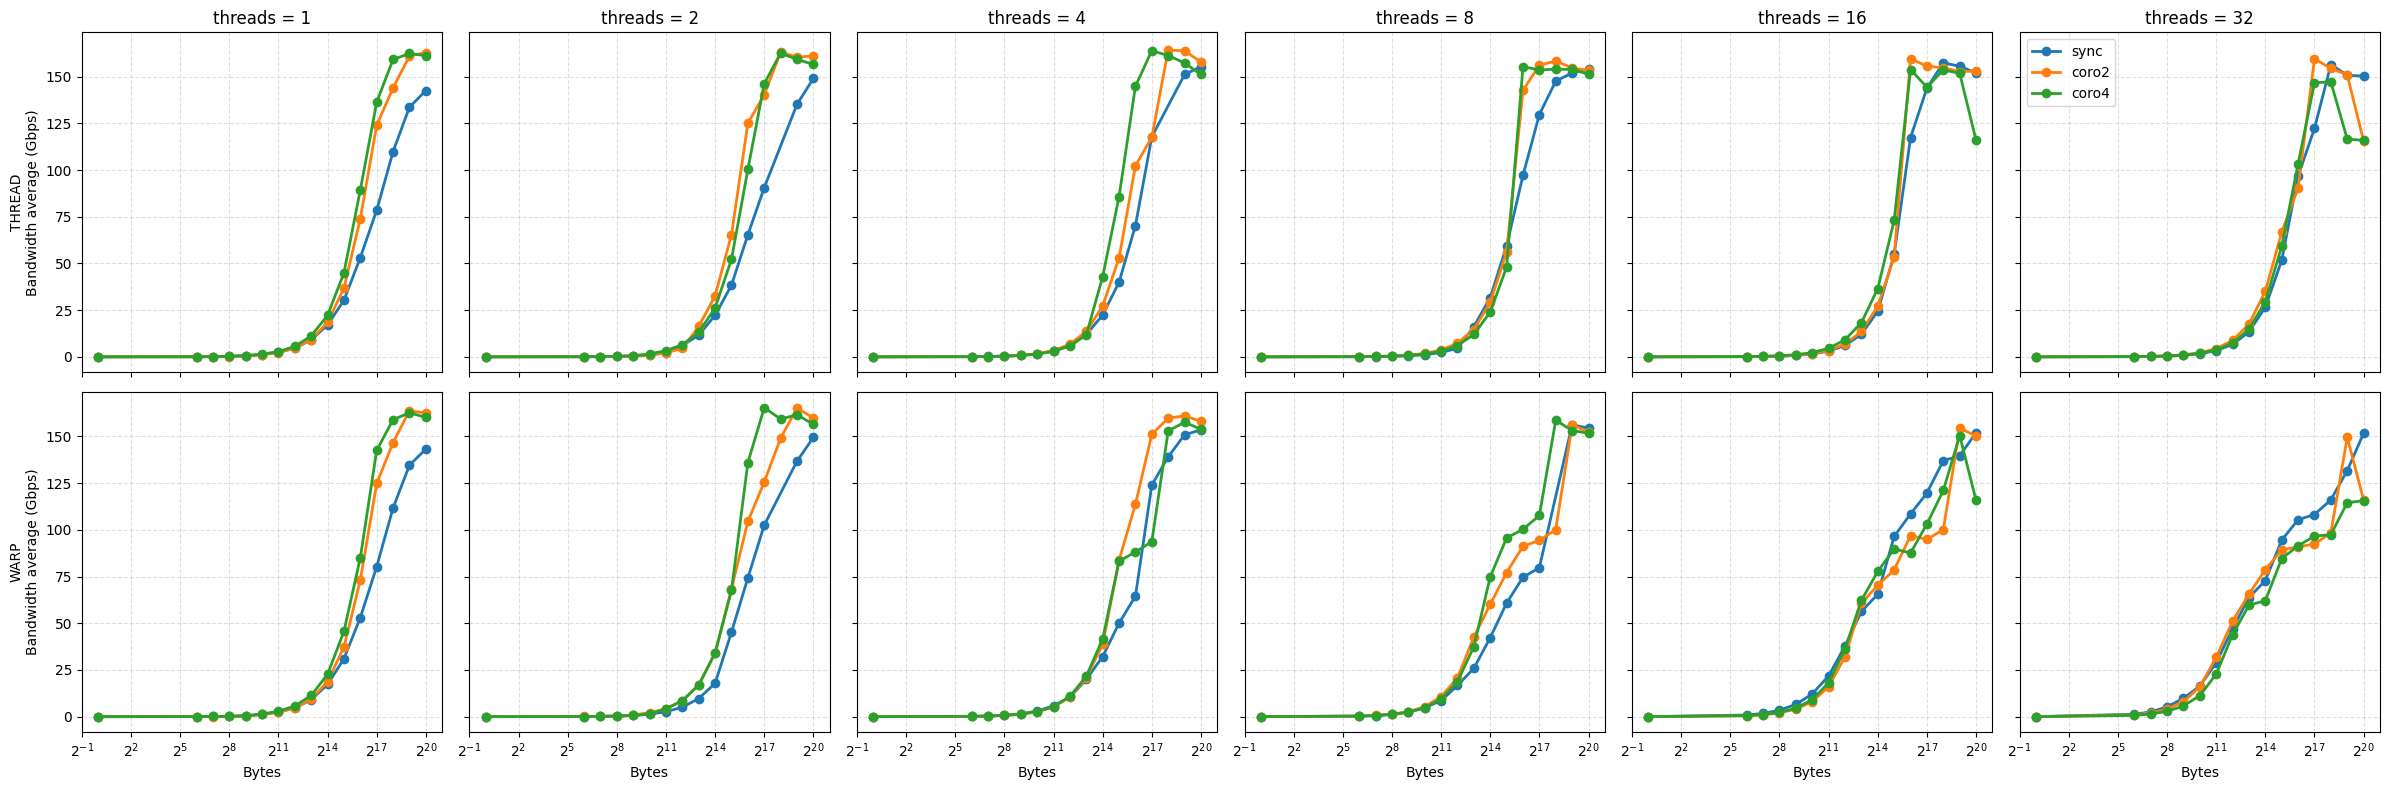

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# 配置
# =========================
files = {
    "sync": "/home/tyh/gpunetio/test/191c_191s/put_bw/put_bw.csv",
    "coro2": "/home/tyh/gpunetio/test/191c_191s/put_bw_coro2/put_bw_coro2.csv",
    "coro4": "/home/tyh/gpunetio/test/191c_191s/put_bw_coro4/put_bw_coro4.csv",
}

scopes = ["THREAD", "WARP"]
threads_list = [1, 2, 4, 8, 16, 32]
versions = ["sync", "coro2", "coro4"]

# =========================
# 读取并合并数据
# =========================
dfs = []

for name, file in files.items():
    path = Path(file)
    if not path.exists():
        raise FileNotFoundError(f"找不到文件: {file}")

    df = pd.read_csv(path)
    df["version"] = name

    # 原始 CSV 中是 bw_average_Gbps，这里转换为 bps
    if "bw_average_bps" not in df.columns:
        df["bw_average_bps"] = df["bw_average_Gbps"] * 1e9

    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# =========================
# bps 转 Gbps
# =========================
data["bw_average_Gbps"] = data["bw_average_bps"] / 1e9

# =========================
# 画图
# =========================
fig, axes = plt.subplots(
    nrows=len(scopes),
    ncols=len(threads_list),
    figsize=(24, 8),
    sharey=True,
    sharex=True,
)

for row, scope in enumerate(scopes):
    for col, threads in enumerate(threads_list):
        ax = axes[row][col]

        sub_df = data[
            (data["scope"] == scope) &
            (data["threads"] == threads)
        ]

        for version in versions:
            vdf = sub_df[sub_df["version"] == version].sort_values("bytes")

            if vdf.empty:
                continue

            ax.plot(
                vdf["bytes"],
                vdf["bw_average_Gbps"],
                marker="o",
                linewidth=2,
                label=version,
            )

        ax.set_xscale("log", base=2)
        ax.grid(True, which="both", linestyle="--", alpha=0.4)

        if row == 0:
            ax.set_title(f"threads = {threads}")

        if col == 0:
            ax.set_ylabel(f"{scope}\nBandwidth average (Gbps)")

        if row == len(scopes) - 1:
            ax.set_xlabel("Bytes")

        if row == 0 and col == len(threads_list) - 1:
            ax.legend()

plt.tight_layout()
plt.show()